### Creating data to view and fit

In [2]:
from  sklearn.datasets import make_circles

# Make 1000 examples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.03,
                    random_state=42)

In [3]:
# Check out features
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [4]:
# Check the labels
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0], dtype=int64)

Visualizing our created data

In [5]:
import pandas as pd
circles = pd.DataFrame({"X0":X[:, 0], "X1":X[:, 1], "label":y})
circles

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


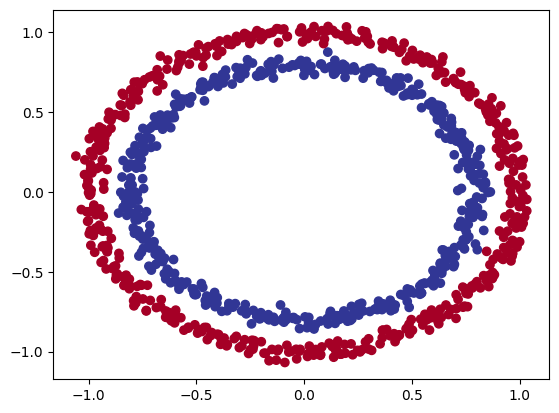

In [6]:
# Visuallize with a plot
import matplotlib.pyplot as plt 
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

### Input and output shapes

In [7]:
# Check the shapes of our features and labels
X.shape, y.shape

((1000, 2), (1000,))

In [8]:
y[:10]

array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0], dtype=int64)

In [9]:
# how many samples we're working 
len(X), len(y)

(1000, 1000)

In [10]:
# View the first example of features and labels
X[5], y[5]

(array([-0.47964637,  0.67643477]), 1)

### Steps in modelling

In [11]:
import tensorflow as tf

# Set the random seed
tf.random.set_seed(42)

# 1. Create the model using the Sequential API
model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["accuracy"])

# 3. Fit the model 
model_1.fit(X, y, epochs=5)



Epoch 1/5


32/32 [==============================] - 1s 2ms/step - loss: 4.2607 - accuracy: 0.4770
Epoch 2/5
32/32 [==============================] - 0s 1ms/step - loss: 3.3347 - accuracy: 0.4620
Epoch 3/5
32/32 [==============================] - 0s 1ms/step - loss: 0.7474 - accuracy: 0.4900
Epoch 4/5
32/32 [==============================] - 0s 1ms/step - loss: 0.7095 - accuracy: 0.4990
Epoch 5/5
32/32 [==============================] - 0s 1ms/step - loss: 0.6987 - accuracy: 0.4930


In [12]:
# Let's try and improve our model by training for longer
model_1.fit(X, y, epochs=200, verbose=0)

In [13]:
# Evaluation
model_1.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.6935 - accuracy: 0.5000


[0.6934831142425537, 0.5]

In [14]:
# let's add extra layer

# Set the random seed
tf.random.set_seed(42)

# 1. Create a model, this time with 2 layers
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(1),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
               optimizer=tf.keras.optimizers.SGD(),
               metrics=["accuracy"])

# 3. Fit the model
model_2.fit(X, y, epochs=100, verbose=0)

In [15]:
# 4. Evaluate the model
model_2.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.6933 - accuracy: 0.5000


[0.6932973861694336, 0.5]

### Improving our model

In [16]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create the model (this time 3 layers)
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_3.compile(loss=tf.keras.losses.BinaryCrossentropy(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

# 3. Fit the model
model_3.fit(X, y, epochs=100)

Epoch 1/100
32/32 [==============================] - 1s 2ms/step - loss: 1.8375 - accuracy: 0.5000
Epoch 2/100
32/32 [==============================] - 0s 1ms/step - loss: 0.7065 - accuracy: 0.4690
Epoch 3/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6948 - accuracy: 0.4850
Epoch 4/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6958 - accuracy: 0.4800
Epoch 5/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6956 - accuracy: 0.4810
Epoch 6/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6958 - accuracy: 0.4500
Epoch 7/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6950 - accuracy: 0.5010
Epoch 8/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6953 - accuracy: 0.5040
Epoch 9/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6972 - accuracy: 0.4890
Epoch 10/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6951 - accuracy: 0.4760
Epoch 11/

In [17]:
# 4. Evaluate the model
model_3.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.6978 - accuracy: 0.5080


[0.6977921724319458, 0.5080000162124634]

To visualize our model's predictions, let's create a function `plot_decision_boundary()`, this function will:
* Take in a trained model, features (X) and labels (y)
* Create a meshgrid of the different X values
* Make preditions across the meshgrid
* Plot the predictions as well as a line between zones (where each unique class falss)

In [18]:
import numpy as np

In [19]:
import numpy as np 
def plot_decision_boundary(model, X, y):
    """
    Plots the decision boundary created by a model predicting on X.
    """
    # Define the axis boundaries of the plot and create a meshgrid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # Create X value (we're going to make predictions on these)
    x_in = np.c_[xx.ravel(), yy.ravel()] # stack 2D arrays together
    
    # Make predictions
    y_pred = model.predict(x_in)
    
    # Check for multi-class
    if len(y_pred[0]) > 1:
        print("doing multiclass classification")
        # We have to reshape our prediction to get them ready for plotting
        y_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)
    else:
        print("doing binary classification")
        y_pred = np.round(y_pred).reshape(xx.shape)
        
    # Plot the decision boundary
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

313/313 [==============================] - 0s 1ms/step
doing binary classification


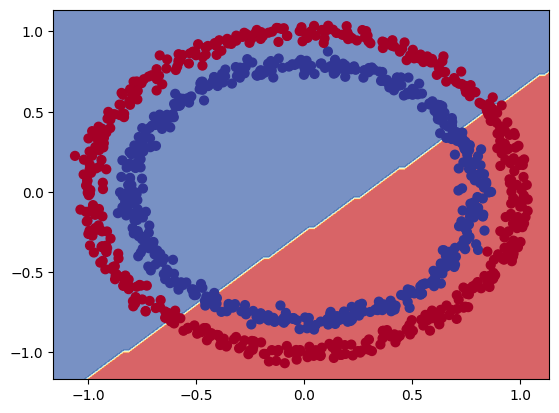

In [20]:
# Check out the predictions our model is making
plot_decision_boundary(model=model_3,
                       X=X,
                       y=y)

### The missing piece : Non Linearity

In [21]:
# Set tje random seed
tf.random.set_seed(42)

# 1. Create the model
model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.linear)
])

# 2. Compile the model
model_4.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(lr=0.001),
                metrics=["accuracy"])

# 3. Fit the model
history = model_4.fit(X, y, epochs=100)

Epoch 1/100
32/32 [==============================] - 0s 1ms/step - loss: 6.1263 - accuracy: 0.4880
Epoch 2/100
32/32 [==============================] - 0s 1ms/step - loss: 6.1217 - accuracy: 0.4870
Epoch 3/100
32/32 [==============================] - 0s 1ms/step - loss: 6.1119 - accuracy: 0.4870
Epoch 4/100
32/32 [==============================] - 0s 1ms/step - loss: 6.0858 - accuracy: 0.4870
Epoch 5/100
32/32 [==============================] - 0s 1ms/step - loss: 6.0836 - accuracy: 0.4870
Epoch 6/100
32/32 [==============================] - 0s 2ms/step - loss: 6.0823 - accuracy: 0.4870
Epoch 7/100
32/32 [==============================] - 0s 2ms/step - loss: 6.0812 - accuracy: 0.4870
Epoch 8/100
32/32 [==============================] - 0s 1ms/step - loss: 6.0803 - accuracy: 0.4870
Epoch 9/100
32/32 [==============================] - 0s 1ms/step - loss: 6.0795 - accuracy: 0.4870
Epoch 10/100
32/32 [==============================] - 0s 1ms/step - loss: 6.0787 - accuracy: 0.4870
Epoch 11/

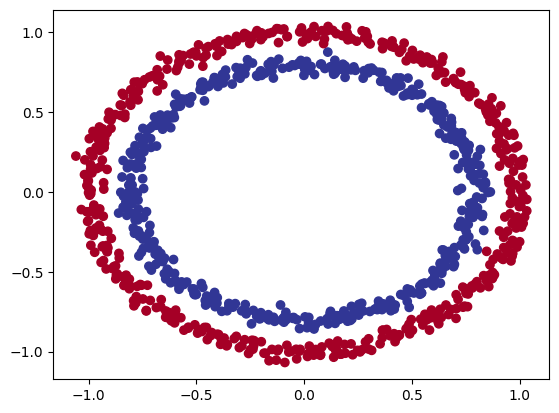

In [22]:
# Check out our data 
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

313/313 [==============================] - 0s 1ms/step
doing binary classification


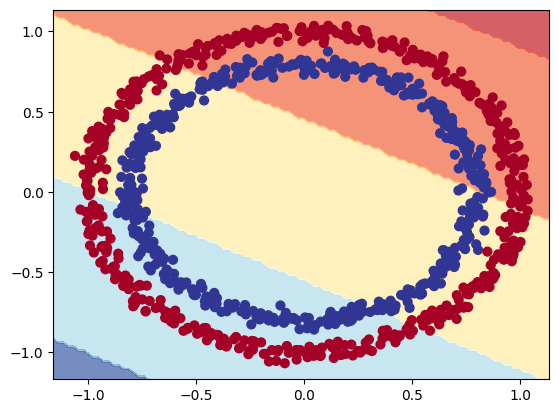

In [24]:
# Check the decision boundary for our latest model
plot_decision_boundary(model=model_4,
                       X=X,
                       y=y)

### let's try build our first neural network with a non-linear activation function

In [29]:
# Set random seed
tf.random.set_seed(42)

# 1. Create a model with a non-linear activation
model_5 = tf.keras.Sequential([
    tf.keras.layers.Dense(1, activation=tf.keras.activations.relu)
])

# 2. Compile the model
model_5.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(lr=0.001),
                metrics=["accuracy"])

# 3. Fit the model
history = model_5.fit(X, y, epochs=100)

Epoch 1/100
32/32 [==============================] - 1s 2ms/step - loss: 6.0801 - accuracy: 0.4870
Epoch 2/100
32/32 [==============================] - 0s 1ms/step - loss: 6.0650 - accuracy: 0.4870
Epoch 3/100
32/32 [==============================] - 0s 1ms/step - loss: 6.0415 - accuracy: 0.4860
Epoch 4/100
32/32 [==============================] - 0s 1ms/step - loss: 6.0378 - accuracy: 0.4840
Epoch 5/100
32/32 [==============================] - 0s 1ms/step - loss: 6.0354 - accuracy: 0.4840
Epoch 6/100
32/32 [==============================] - 0s 1ms/step - loss: 6.0329 - accuracy: 0.4850
Epoch 7/100
32/32 [==============================] - 0s 1ms/step - loss: 6.0141 - accuracy: 0.4850
Epoch 8/100
32/32 [==============================] - 0s 2ms/step - loss: 5.9903 - accuracy: 0.4850
Epoch 9/100
32/32 [==============================] - 0s 1ms/step - loss: 5.9758 - accuracy: 0.4850
Epoch 10/100
32/32 [==============================] - 0s 2ms/step - loss: 5.9820 - accuracy: 0.4850
Epoch 11/

In [36]:
# Time to replicate the multi-layer neural network from TensorFLow playground

# Set the random seed
tf.random.set_seed(42)

# 1. Create the model
model_6 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model_6.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(lr=0.001),
                metrics=["accuracy"])

# 3. Fit the model
history = model_6.fit(X, y, epochs=250)

Epoch 1/250
32/32 [==============================] - 1s 2ms/step - loss: 3.5131 - accuracy: 0.5000
Epoch 2/250
32/32 [==============================] - 0s 2ms/step - loss: 2.7091 - accuracy: 0.4790
Epoch 3/250
32/32 [==============================] - 0s 2ms/step - loss: 1.8852 - accuracy: 0.4410
Epoch 4/250
32/32 [==============================] - 0s 1ms/step - loss: 1.5752 - accuracy: 0.4590
Epoch 5/250
32/32 [==============================] - 0s 1ms/step - loss: 1.3353 - accuracy: 0.4650
Epoch 6/250
32/32 [==============================] - 0s 1ms/step - loss: 1.1121 - accuracy: 0.4740
Epoch 7/250
32/32 [==============================] - 0s 1ms/step - loss: 1.0491 - accuracy: 0.4760
Epoch 8/250
32/32 [==============================] - 0s 1ms/step - loss: 1.0083 - accuracy: 0.4780
Epoch 9/250
32/32 [==============================] - 0s 3ms/step - loss: 0.9677 - accuracy: 0.4810
Epoch 10/250
32/32 [==============================] - 0s 3ms/step - loss: 0.9231 - accuracy: 0.4790
Epoch 11/

In [37]:
# Evaluate the model
model_6.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.0611 - accuracy: 0.9930


[0.06114717945456505, 0.9929999709129333]

313/313 [==============================] - 0s 946us/step
doing binary classification


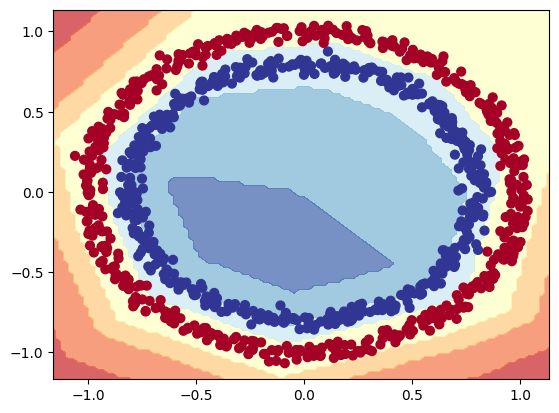

In [38]:
plot_decision_boundary(model=model_6,
                       X=X,
                       y=y)

In [39]:
# Set random seed
tf.random.set_seed(42)

# 1. Create the model
model_7 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2. Compile the model
model_7.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                metrics=["accuracy"])

# 3. Fit the model
model_7.fit(X, y, epochs=100)

Epoch 1/100
32/32 [==============================] - 1s 2ms/step - loss: 0.7054 - accuracy: 0.4970
Epoch 2/100
32/32 [==============================] - 0s 1ms/step - loss: 0.7006 - accuracy: 0.4920
Epoch 3/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6978 - accuracy: 0.4930
Epoch 4/100
32/32 [==============================] - 0s 1ms/step - loss: 0.6961 - accuracy: 0.4940
Epoch 5/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6948 - accuracy: 0.4940
Epoch 6/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6936 - accuracy: 0.4930
Epoch 7/100
32/32 [==============================] - 0s 5ms/step - loss: 0.6921 - accuracy: 0.4950
Epoch 8/100
32/32 [==============================] - 0s 4ms/step - loss: 0.6910 - accuracy: 0.4920
Epoch 9/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6896 - accuracy: 0.4950
Epoch 10/100
32/32 [==============================] - 0s 2ms/step - loss: 0.6885 - accuracy: 0.4940
Epoch 11/

In [40]:
# 4. Evalute the model
model_7.evaluate(X, y)

32/32 [==============================] - 0s 1ms/step - loss: 0.3493 - accuracy: 0.9560


[0.3492540717124939, 0.9559999704360962]

313/313 [==============================] - 0s 991us/step
doing binary classification


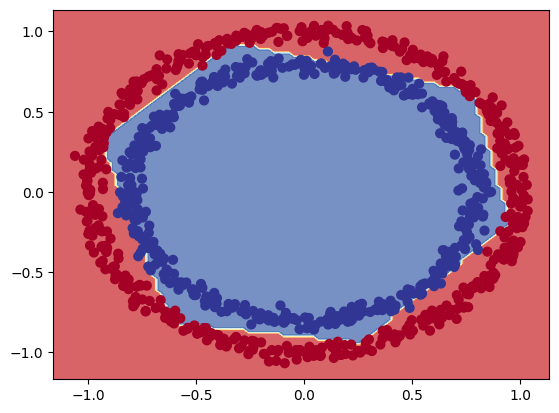

In [41]:
# Let's visualize our model_7
plot_decision_boundary(model_7, X, y)

In [42]:
# Split the dataset into train and test
X_train, y_train = X[:800], y[:800]
X_test, y_test = X[800:], y[800:]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 2), (200, 2), (800,), (200,))

In [46]:
# Let's recreate a model to fit on the training data and evaluate on the testing data

# Set random seed
tf.random.set_seed(42)

# 1. Create the model (same as model_7)
model_8 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid") 
])

# 2. Compile the model
model_8.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=["accuracy"])

# 3. Fit the model
history = model_8.fit(X_train, y_train, epochs=25)

Epoch 1/25
25/25 [==============================] - 1s 2ms/step - loss: 0.6963 - accuracy: 0.4863
Epoch 2/25
25/25 [==============================] - 0s 2ms/step - loss: 0.6899 - accuracy: 0.4988
Epoch 3/25
25/25 [==============================] - 0s 2ms/step - loss: 0.6849 - accuracy: 0.5175
Epoch 4/25
25/25 [==============================] - 0s 2ms/step - loss: 0.6785 - accuracy: 0.5537
Epoch 5/25
25/25 [==============================] - 0s 2ms/step - loss: 0.6707 - accuracy: 0.5863
Epoch 6/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6600 - accuracy: 0.6112
Epoch 7/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6459 - accuracy: 0.6363
Epoch 8/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6309 - accuracy: 0.6575
Epoch 9/25
25/25 [==============================] - 0s 1ms/step - loss: 0.6034 - accuracy: 0.7188
Epoch 10/25
25/25 [==============================] - 0s 1ms/step - loss: 0.5638 - accuracy: 0.8000
Epoch 11/25
25/25 [

In [47]:
# 4. Evaluate the model
model_8.evaluate(X_test, y_test)

7/7 [==============================] - 0s 1ms/step - loss: 0.2585 - accuracy: 0.9300


[0.2584820091724396, 0.9300000071525574]

313/313 [==============================] - 0s 920us/step
doing binary classification
313/313 [==============================] - 0s 942us/step
doing binary classification


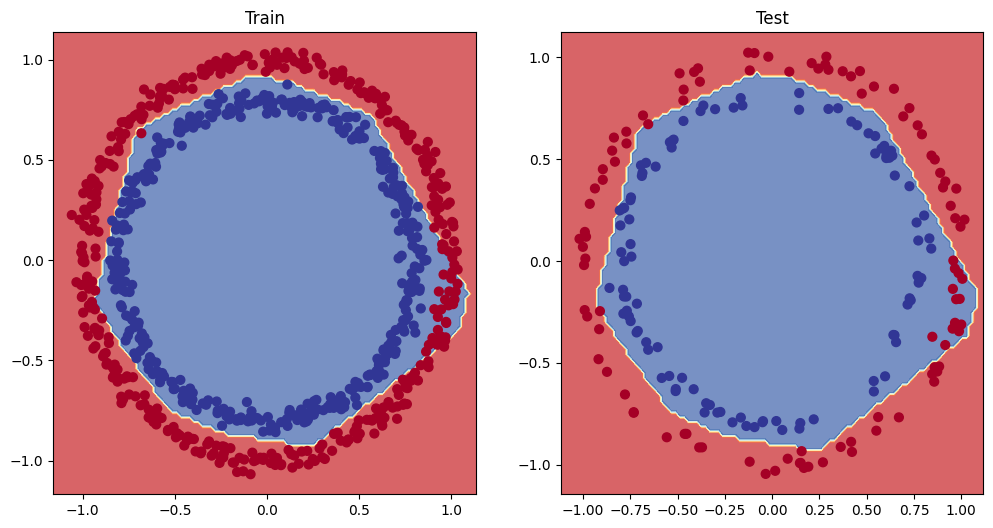

In [51]:
# Plot the decision boundaries for the training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_8, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_8, X_test, y_test)
plt.show()

### Plotting loss curve

In [52]:
# Convert the history object into a DataFrame
pd.DataFrame(history.history)

,loss,accuracy
0,0.696341,0.48625
1,0.689941,0.49875
2,0.684941,0.51750
3,0.678459,0.55375
4,0.670712,0.58625
5,0.659984,0.61125
6,0.645865,0.63625
7,0.630948,0.65750
8,0.603361,0.71875
9,0.563850,0.80000


Text(0.5, 1.0, 'Model_8 loss curves')

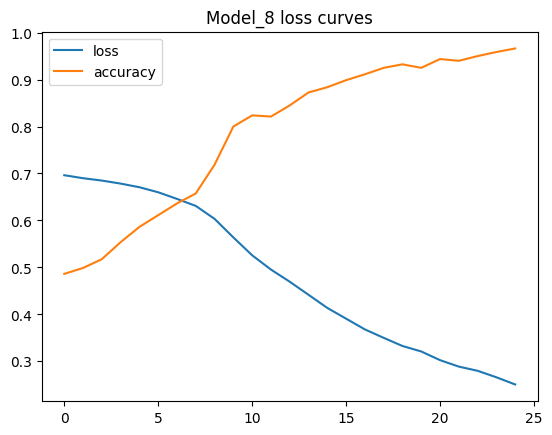

In [53]:
# Plot the loss curves
pd.DataFrame(history.history).plot()
plt.title("Model_8 loss curves")